<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/JS06/JS06-05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# **Klasifikasi 2 - Lab 5**


---

---


# **Persiapan - Mount Google Drive**


---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# folder data praktikum di Google Drive
base_path = '/content/drive/MyDrive/COLLEGE/SEM 5/PEMMES/DATA/images-week06'
print('Lokasi data:', base_path)

Mounted at /content/drive
Lokasi data: /content/drive/MyDrive/COLLEGE/SEM 5/PEMMES/DATA/images-week06


> Data dibaca dari folder `images-week06` di Google Drive, jadi Drive di-mount terlebih dahulu dan lokasinya disimpan pada variabel `base_path`.

---


# **Langkah 0 - Import Library**


---

In [2]:
# Import Required Libraries
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

In [3]:
# Image directories
train_dir = base_path + "/images/training/"
test_dir = base_path + "/images/test/"

---


# **Langkah 1 - Load Data dan Visualisasikan**


---

In [4]:
def load_dataset(img_dir):
    p = Path(img_dir)
    # ambil hanya folder kelas (day / night), abaikan file tersembunyi
    dirs = [d for d in p.iterdir() if d.is_dir() and not d.name.startswith('.')]

    img_list = []

    for dir in dirs:
        label = dir.name   # nama folder dipakai sebagai label
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))

    return img_list

In [5]:
# Load training data
train_img = load_dataset(train_dir)

In [6]:
# Check the first data
# It should be a tuple consist of arrays of image and image labels
train_img[0]

(array([[[78, 78, 76],
         [75, 76, 71],
         [72, 73, 68],
         ...,
         [61, 59, 60],
         [71, 69, 70],
         [77, 75, 76]],
 
        [[77, 77, 75],
         [74, 75, 70],
         [71, 72, 66],
         ...,
         [49, 47, 48],
         [53, 51, 52],
         [55, 53, 54]],
 
        [[75, 76, 71],
         [73, 74, 69],
         [69, 70, 64],
         ...,
         [41, 39, 40],
         [39, 37, 38],
         [38, 36, 37]],
 
        ...,
 
        [[88, 72, 59],
         [86, 72, 59],
         [88, 72, 59],
         ...,
         [67, 54, 48],
         [67, 54, 48],
         [67, 54, 48]],
 
        [[87, 73, 62],
         [87, 75, 63],
         [88, 74, 63],
         ...,
         [67, 54, 48],
         [67, 54, 48],
         [67, 54, 48]],
 
        [[88, 76, 64],
         [88, 76, 64],
         [89, 77, 65],
         ...,
         [67, 54, 48],
         [67, 54, 48],
         [67, 54, 48]]], dtype=uint8),
 'night')

In [7]:
# Random size checking
pick_random = np.random.randint(0, len(train_img))

# Check img size
print(f'Image {pick_random}')
print(train_img[pick_random][0].shape)

Image 155
(471, 640, 3)


In [8]:
# Function to Visualize
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))

    img = img_list[rand_num][0]
    label = img_list[rand_num][1]
    label_str = 'day' if label == 1 else 'night'

    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

Shape	: (737, 1024, 3)
Label	: night


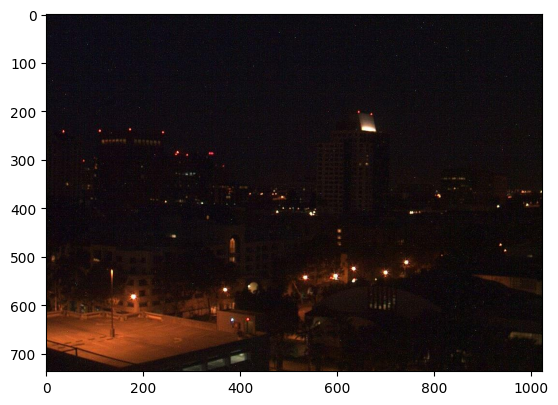

In [9]:
random_img_viz(train_img)

---


# **Langkah 2 - Cek Jumlah Data**


---

In [10]:
from collections import Counter

print('Jumlah data training:', len(train_img), dict(Counter([lbl for _, lbl in train_img])))

Jumlah data training: 240 {'night': 120, 'day': 120}


---


# **Langkah 3 - Pra Pengolahan Data**


---

In [11]:
def standarized_input(image):
    # resize to w: 1100, h:600
    std_img = cv2.resize(image, (1100,600))

    return std_img

In [12]:
def label_encoder(label):
    # Encode the label
    # day as 1; night as 0
    num_val = 0

    if(label == 'day'):
        num_val = 1

    return num_val

In [13]:
def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        # Standarized the image
        std_img = standarized_input(image)

        # Create the label
        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))

    return std_img_list

In [14]:
train_std_img_list = preprocess(train_img)

In [15]:
# Random size checking
pick_random = np.random.randint(0, len(train_std_img_list))

# Check img size
print(f'Image {pick_random}')
print(train_std_img_list[pick_random][0].shape)

Image 169
(600, 1100, 3)


Shape	: (600, 1100, 3)
Label	: 0


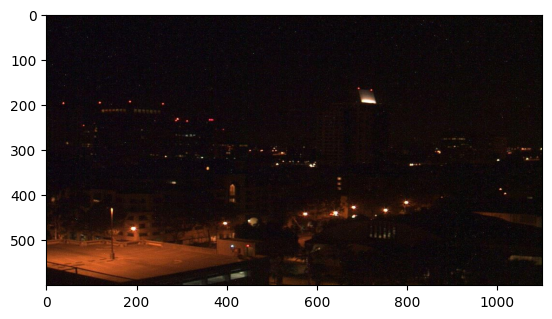

In [16]:
random_img_viz(train_std_img_list)

---


# **Langkah 4 - Ekstraksi Fitur**


---

In [17]:
# Get feature based on average brightness using HSV colorspace
def avg_brightness(image):
    # Convert image to HSV
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Calculate the avg of brightness
    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rb value which is the V channel
    area = image.shape[0] * image.shape[1]
    avg = sum_brightness / area

    return avg

Image 196
Avg Brighness: 123.2517


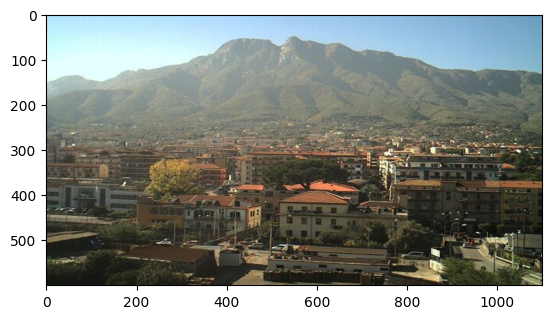

In [18]:
# Check on random image
rand_img = np.random.randint(0, len(train_std_img_list))

feature_img = train_std_img_list[rand_img][0]

avg_img = avg_brightness(feature_img)

print(f'Image {rand_img}')
print(f'Avg Brighness: {avg_img:.4f}')
plt.imshow(feature_img)

In [19]:
# Ringkasan rata-rata brightness untuk seluruh data training (per kelas)
brightness_df = pd.DataFrame({
    'label': ['day' if lbl == 1 else 'night' for _, lbl in train_std_img_list],
    'avg_brightness': [avg_brightness(img) for img, _ in train_std_img_list]
})
brightness_df.groupby('label')['avg_brightness'].agg(['count', 'mean', 'min', 'max']).round(2)

,count,mean,min,max
label,,,,
day,120,137.33,94.55,200.02
night,120,69.17,8.11,119.60


> Gambar yang muncul pada pengecekan acak berbeda tiap kali sel dijalankan, jadi nilai brightness-nya juga ikut berubah. Contohnya, citra siang bisa bernilai sekitar 154, sedangkan citra malam jauh lebih rendah. Supaya tidak bergantung pada satu gambar acak, ringkasan seluruh data training di atas menunjukkan bahwa citra siang rata-rata bernilai 137,33 (rentang 94,55 sampai 200,02), sedangkan citra malam rata-rata 69,17 (rentang 8,11 sampai 119,60). Jadi, brightness memang bisa membedakan siang dan malam. Namun rentang keduanya masih bertumpang tindih di sekitar 95 sampai 120, sehingga citra siang yang agak gelap (misalnya mendung) berisiko terbaca sebagai malam.

---


# **Langkah 5 - Klasifikasi dengan Metode Threshold**


---

In [20]:
def predict_label(img, threshold):
    # Computer average brightness
    avg = avg_brightness(img)
    pred = 0

    # Predict the label based on user defined threshold
    if avg > threshold:
        pred = 1

    return pred

Image 13
Actual label: 0
Predicted label: 0


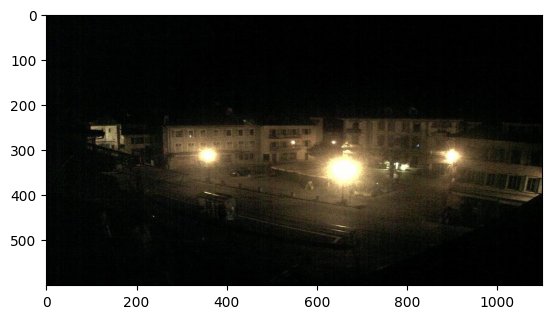

In [21]:
# Test the classifier on train data
rand_img = np.random.randint(0, len(train_std_img_list))

pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

# Evaluate
print(f'Image {rand_img}')
print(f'Actual label: {train_std_img_list[rand_img][1]}')
print(f'Predicted label: {pred}')
plt.imshow(train_std_img_list[rand_img][0])

---


# **Langkah 6 - Evaluasi Manual**


---

In [22]:
def evaluate(img_list, threshold):
    miss_labels = []

    for file in img_list:
        # Get the ground truth / correct label
        img = file[0]
        label = file[1]

        # Get prediction
        pred_label = predict_label(img, threshold)

        # Compare ground truth and pred
        if pred_label != label:
            miss_labels.append((img, pred_label, label))

    total_img = len(img_list)
    corr_pred = total_img - len(miss_labels)
    accuracy = corr_pred / total_img

    print(f'Accuracy: {accuracy:.4f}')

In [23]:
# Evaluate on train data
evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


In [24]:
# Evaluate on test data

# Load test data
test_img = load_dataset(test_dir)

# Preprocess
test_std_img_list = preprocess(test_img)

# Predict
evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


In [25]:
# coba beberapa nilai ambang batas
for th in [80, 100, 120, 140]:
    print(f'Threshold {th}:', end=' ')
    evaluate(test_std_img_list, threshold=th)

Threshold 80: Accuracy: 0.7875
Threshold 100: Accuracy: 0.9250
Threshold 120: Accuracy: 0.8688
Threshold 140: Accuracy: 0.7438


> Dengan threshold 120, akurasi data training 0,8417 dan data testing 0,8688. Ketika threshold diubah-ubah pada data testing, akurasinya berubah cukup jauh: 0,7875 (threshold 80), 0,9250 (100), 0,8688 (120), dan 0,7438 (140). Jadi, metode ini sangat bergantung pada nilai ambang batas yang kita tentukan sendiri lewat coba-coba. Perlu dicatat juga bahwa threshold 100 dipilih berdasarkan data testing, sehingga hasil 0,9250 itu belum bisa dianggap murni.

---


# **Klasifikasi dengan SVM**


---

---


# **Langkah 4 Alternatif - Membuat Feature Vectors**


---

In [26]:
# Create function to extract feature for every images and stored in tabular data
# Stored in Pandas dataframe
def extract_avg_bright_feature(img_list):
    avg_list = []
    labels = []

    for img in img_list:
        img_avg = avg_brightness(img[0]) # Get the avg brightness from image
        img_label = img[1] # Get the image label

        avg_list.append(img_avg)
        labels.append(img_label)

    # Stack data in columcular way
    data = np.column_stack((avg_list, labels))
    # Create a Pandas dataframe
    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

    return df

In [27]:
# Extract feature on train data
train_avg_img = extract_avg_bright_feature(train_std_img_list)
print(f'Shape: {train_avg_img.shape}')
train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,99.623588,0.0
1,35.963767,0.0
2,101.579750,0.0
3,38.835795,0.0
4,85.889741,0.0


In [28]:
# Do the same thing on test data
test_avg_img = extract_avg_bright_feature(test_std_img_list)
print(f'Shape: {test_avg_img.shape}')
test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,157.918309,1.0
1,183.717738,1.0
2,132.523694,1.0
3,127.443791,1.0
4,150.264005,1.0


---


# **Langkah 5 - Buat Model SVM**


---

In [29]:
# import requied library
from sklearn.svm import SVC

# Split data and label
X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
y_train = train_avg_img.iloc[:,1]
X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
y_test = test_avg_img.iloc[:,1]

model = SVC()
model.fit(X_train, y_train)

SVC()

---


# **Langkah 6 - Evaluasi**


---

In [30]:
from sklearn.metrics import accuracy_score

# Make a prediction on train data
y_train_pred = model.predict(X_train)

# Get the accuracy on train data
acc_train = accuracy_score(y_train, y_train_pred)

# Make a prediction on test data
y_test_pred = model.predict(X_test)

# Get the accuracy on test data
acc_test = accuracy_score(y_test, y_test_pred)

# Print Eval Result
print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9


> Dengan SVM (kernel RBF default), akurasi training 0,8583 dan akurasi testing 0,9. Hasil ini lebih baik dibandingkan threshold 120 (0,8417 dan 0,8688), karena SVM menentukan batas keputusan sendiri dari data sehingga kita tidak perlu mencari threshold secara manual. Akurasi testing yang sedikit lebih tinggi dari training menandakan model tidak overfitting. Meskipun demikian, fitur yang dipakai hanya satu (rata-rata brightness), jadi citra siang yang gelap (misalnya mendung) atau citra malam yang terang karena lampu masih sulit dibedakan.